# WSI - Ćwiczenie 2: Algorytmy Ewolucyjne
**Optymalizacja warunków w szklarniach pomidorów (Solanum lycopersicum L.)**

Celem ćwiczenia jest minimalizacja funkcji błędu przy użyciu dwóch różnych podejść ewolucyjnych. Limit ewaluacji funkcji celu wynosi równe 9000. Problem jest 10 wymiarowy, czyli w naszym przypadku ma 10 parametrów sterownika klimatu.

Rozpatrujemy dwa przypadki:
* **Przypadek A:** Algorytm Genetycznetyczny z kodowaniem binarnym (8 bitów na parametr), selekcją turniejową, krzyżowaniem dwupunktowym i mutacją binarną.
* **Przypadek B:** Strategia Ewolucyjna z reprezentacją rzeczywistą w schemacie $(\mu, 100)$, krzyżowaniem arytmetycznym i mutacją gaussowską z samoadaptacją parametru $\sigma$.

In [29]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Import algorytmów z przygotowanych plików
from genetic_algorythym.genetic_algorythym import genetic_evolution
from genetic_algorythym.genetic_algorythym_prameters import return_genetic_algorithm_parameters

from evolution_algorythym.evolution_algorytym import evolution_strategy
from evolution_algorythym.evolution_algorythym_prameters import return_evolutionary_strategy_parameters

# Ustawienia ogólne
MAX_EVALUATIONS = 9000
DIMENSIONS = 10

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Przypadek A: Algorytm Genetyczny (Kodowanie Binarne)
Zgodnie z poleceniem testujemy 3 różne wielkości turnieju $k$. Parametry:
* Populacja: 100
* Liczba pokoleń: 90 (daje to 9000 ewaluacji, ponieważ w każdym pokoleniu krzyżujemy do uzyskania populacji wielkości 100).
* Prawdopodobieństwo mutacji: $p_m = 1/L$, gdzie $L = 80$ (10 parametrów * 8 bitów).

In [30]:
# Pobranie domyślnych parametrów i nadpisanie ich na potrzeby eksperymentu
ga_params = return_genetic_algorithm_parameters()
ga_params["population_size"] = 100
ga_params["generations"] = MAX_EVALUATIONS // 100  # 90 pokoleń

# Wartości rozmiaru turnieju do przetestowania
k_values = [2, 5, 10]
ga_results_history = {}
ga_best_fitnesses = {}

for k in k_values:
    print(f"Uruchamianie GA dla rozmiaru turnieju k={k}...")
    ga_params["tournament_size"] = k

    ga = genetic_evolution(**ga_params)

    # Zakładamy, że metoda genetic_algorithm została poprawiona, aby zwracać 3 elementy
    # Jeśli zwraca tylko dwa, poniższy kod wymaga dostosowania (np. zapisywania historii z logów)
    best_chrom, best_fit, history = ga.genetic_algorithm()

    ga_results_history[k] = history
    ga_best_fitnesses[k] = best_fit

print("\nWyniki dla Przypadku A:")
for k, fit in ga_best_fitnesses.items():
    print(f"Turniej k={k} -> Najlepszy błąd: {fit:.4f}")


Uruchamianie GA dla rozmiaru turnieju k=2...
Uruchamianie GA dla rozmiaru turnieju k=5...
Uruchamianie GA dla rozmiaru turnieju k=10...

Wyniki dla Przypadku A:
Turniej k=2 -> Najlepszy błąd: 4.9060
Turniej k=5 -> Najlepszy błąd: 11.3691
Turniej k=10 -> Najlepszy błąd: 1.5615


## Przypadek B: Strategia Ewolucyjna $(\mu, 100)$
Testujemy 3 różne progi selekcji najlepszych osobników z puli ($\mu$). Tak jak poprzednio kąde polenie ma po $\lambda = 100$ wygenerowanych osobników, zatem mamy 90 pokoleń (90 pokoleń * 100 ewaluacji potokowych dzieci = 9000).

In [31]:
from evolution_algorythym.evolution_algorytym import chromosome


es_config = return_evolutionary_strategy_parameters()
es_config["lambda_"] = 100
es_config["generations"] = MAX_EVALUATIONS // 100 # 90 pokoleń

# Wstrzyknięcie zmiennych klasowych wymaganych przez chromosome
chromosome.num_params = es_config["num_params"]
chromosome.sigma_lower_bound = es_config["sigma_lower_bound"]

# Wartości mu do przetestowania
mu_values = [5, 15, 30]
es_results_history = {}
es_best_fitnesses = {}

for mu in mu_values:
    print(f"Uruchamianie Strategii Ewolucyjnej dla mu={mu}...")
    es = evolution_strategy(mu=mu, config=es_config)

    best_ind, best_fitness, history = es.evolution_algorithm()

    es_results_history[mu] = history
    es_best_fitnesses[mu] = best_fitness

print("\nWyniki dla Przypadku B:")
for mu, fit in es_best_fitnesses.items():
    print(f"Pula mu={mu} -> Najlepszy błąd: {fit:.4f}")

Uruchamianie Strategii Ewolucyjnej dla mu=5...
Uruchamianie Strategii Ewolucyjnej dla mu=15...
Uruchamianie Strategii Ewolucyjnej dla mu=30...

Wyniki dla Przypadku B:
Pula mu=5 -> Najlepszy błąd: 3.9599
Pula mu=15 -> Najlepszy błąd: 3.9599
Pula mu=30 -> Najlepszy błąd: 1.9799


## Wizualizacja Wyników i Analiza
Poniżej znajduje się zestawienie konwergencji obu algorytmów. Ze względu na charakter funkcji celu zastosowałem skalę logarytmiczną na osi Y, co ułatwia obserwację zachowania algorytmów blisko optimum.

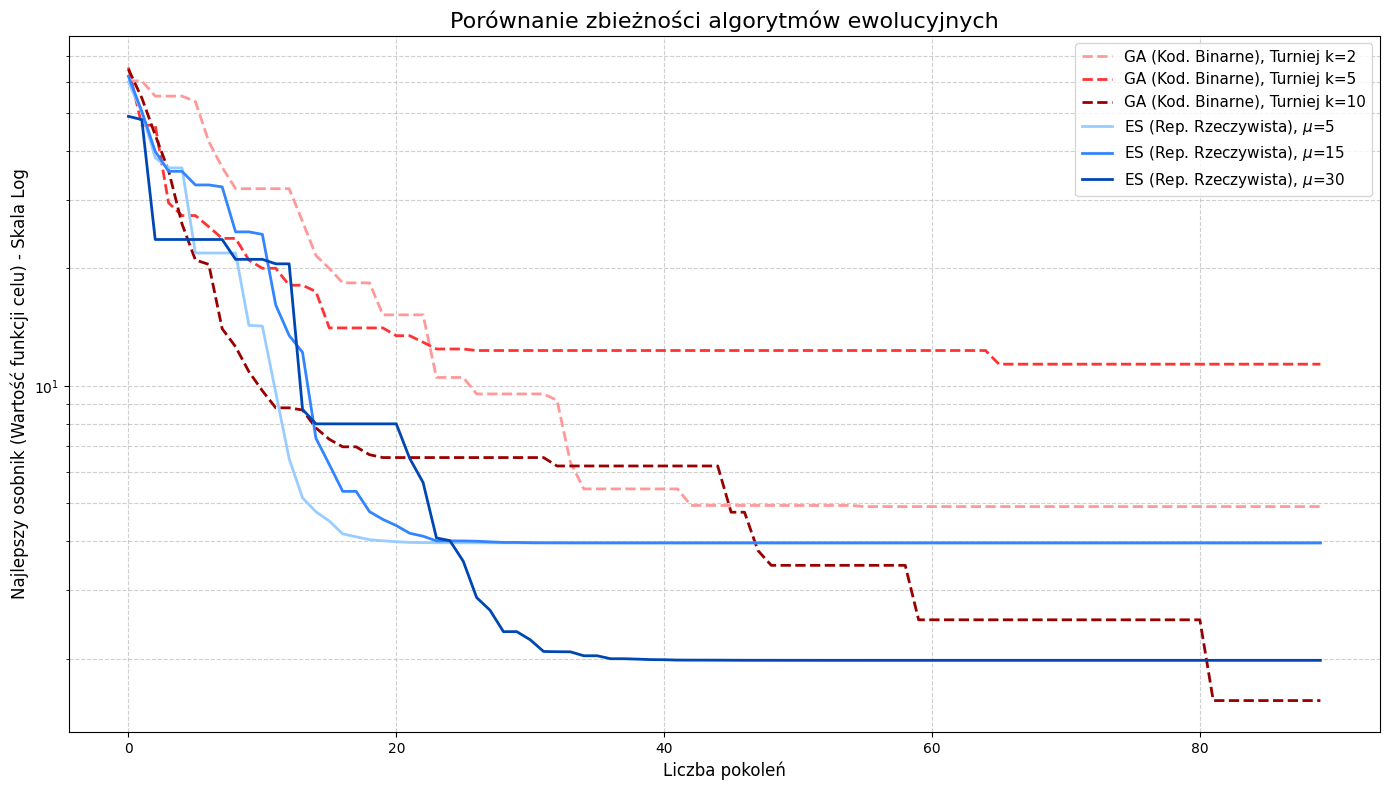

In [32]:
plt.figure(figsize=(14, 8))

# Rysowanie wykresów dla Algorytmu Genetycznego (SGA)
colors_ga = ['#ff9999', '#ff3333', '#990000']
for (k, history), color in zip(ga_results_history.items(), colors_ga):
    plt.plot(history, label=f'GA (Kod. Binarne), Turniej k={k}', linestyle='--', color=color, linewidth=2)

# Rysowanie wykresów dla Strategii Ewolucyjnej (ES)
colors_es = ['#99ccff', '#3385ff', '#0047b3']
for (mu, history), color in zip(es_results_history.items(), colors_es):
    plt.plot(history, label=rf'ES (Rep. Rzeczywista), $\mu$={mu}', linestyle='-', color=color, linewidth=2)

plt.title('Porównanie zbieżności algorytmów ewolucyjnych', fontsize=16)
plt.xlabel('Liczba pokoleń', fontsize=12)
plt.ylabel('Najlepszy osobnik (Wartość funkcji celu) - Skala Log', fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Wnioski i Interpretacja

**1. Różnice między reprezentacjami (Binarna vs Rzeczywista):**
* Strategia ewolucyjna (Przypadek B) korzystająca z reprezentacji rzeczywistej i mutacji gaussowskiej zazwyczaj osiąga znacznie lepsze (niższe) wyniki na funkcjach ciągłych z wieloma minimami lokalnymi niż klasyczny wariant binarny. Wynika to z faktu, że mechanizm samoadaptacji parametru $\sigma$ potrafi dynamicznie zmniejszać promień przeszukiwania, gdy algorytm zbliża się do optymalnego rozwiązania (tzw. eksploatacja).
* Algorytm binarny (Przypadek A) cierpi z powodu tzw. "szumu precyzji" – operuje na 8 bitach co mocno kwantuje przestrzeń rozwiązań, uniemożliwiając precyzyjne dotarcie do idealnego zera.

**2. Analiza parametrów - Rozmiar turnieju ($k$) w GA:**
* Małe $k$ (np. 2): Mniejsza presja selekcyjna. Algorytm eksploruje szerzej, ale zbiega wolniej.
* Duże $k$ (np. 10): Bardzo silna presja selekcyjna. Promuje najlepszych, co przyspiesza spadek błędu w pierwszych pokoleniach, ale zwiększa ryzyko przedwczesnej zbieżności (utknięcia w minimum lokalnym).

**3. Analiza parametrów - Próg selekcji ($\mu$) w ES:**
* Niskie $\mu$ (np. 5): Bardzo "zachłanna" strategia. Z populacji potomnej 100 osobników wybieranych jest zaledwie 5 najlepszych do reprodukcji. Pozwala to na gwałtowny spadek błędu, ale drastycznie redukuje różnorodność genetyczną.
* Wyższe $\mu$ (np. 30): Bardziej zrównoważone podejście. Przekazanie większej puli osobników do krzyżowania arytmetycznego sprawia, że algorytm zachowuje więcej różnorodności, radząc sobie lepiej z wychodzeniem z lokalnych minimów kosztem początkowej szybkości zbiegania.